In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.datasets import fetch_covtype
import random
import gc
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
class DatasetHandler:
    def __init__(self):
        self.scaler = StandardScaler()
        self.data = {}

    def load(self, n_samples=150000, target_classes=None):
        print("Загрузка Forest Covertype (54 признака, 7 классов)...")
        data = fetch_covtype()
        X, y = data.data, data.target

        if n_samples < len(X):
            idx = np.random.choice(len(X), n_samples, replace=False)
            X, y = X[idx], y[idx]
            
        self.X = X.astype(np.float32)
        self.y = (y - 1).astype(np.int64)
        print(f"Датасет загружен. Shape: X{self.X.shape}, y{self.y.shape}")

    def preprocess_and_split(self, test_size=0.15, val_size=0.15):
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=42, stratify=self.y)
        
        val_ratio = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_ratio, random_state=42, stratify=y_train_val)

        self.scaler.fit(X_train)
        self.data = {
            'X_train': self.scaler.transform(X_train),
            'y_train': y_train,
            'X_val': self.scaler.transform(X_val),
            'y_val': y_val,
            'X_test': self.scaler.transform(X_test),
            'y_test': y_test
        }
        print("Данные предобработаны и разделены.")
        return self.data

In [3]:
ACT_MAP = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid}

class Individual:
    def __init__(self, hidden_layers=None, neurons_per_layer=None, activation_type=None, reg_coeff=None):
        self.hidden_layers = hidden_layers if hidden_layers is not None else np.random.randint(1, 5)
        self.neurons_per_layer = neurons_per_layer if neurons_per_layer is not None else [int(x) for x in np.random.randint(8, 64, self.hidden_layers)]
        self.activation_type = activation_type if activation_type is not None else [random.choice(list(ACT_MAP.keys())) for _ in range(self.hidden_layers)]
        self.reg_coeff = reg_coeff if reg_coeff is not None else float(np.random.choice([0.0, 0.001, 0.01]))
        self.fitness = None
        self.best_model_state = None

    def decode(self, input_dim, num_classes=7):
        layers = []
        prev_dim = input_dim
        for i in range(self.hidden_layers):
            layers.append(nn.Linear(prev_dim, self.neurons_per_layer[i]))
            layers.append(ACT_MAP[self.activation_type[i]]())
            prev_dim = self.neurons_per_layer[i]
        layers.append(nn.Linear(prev_dim, num_classes))
        return nn.Sequential(*layers)

    def count_params(self, input_dim, num_classes=7):
        params = 0
        prev = input_dim
        for n in self.neurons_per_layer:
            params += prev * n + n
            prev = n
        params += prev * num_classes + num_classes
        return int(params)

    def mutate(self, rate=0.3):
        if random.random() < rate:
            if self.hidden_layers > 1 and random.random() < 0.5:
                idx = random.randint(0, self.hidden_layers - 1)
                self.neurons_per_layer.pop(idx)
                self.activation_type.pop(idx)
                self.hidden_layers -= 1
            elif self.hidden_layers < 5:
                self.neurons_per_layer.append(np.random.randint(8, 64))
                self.activation_type.append(random.choice(list(ACT_MAP.keys())))
                self.hidden_layers += 1

        for i in range(len(self.neurons_per_layer)):
            if random.random() < rate:
                self.neurons_per_layer[i] = max(8, self.neurons_per_layer[i] + np.random.randint(-8, 8))

        for i in range(len(self.activation_type)):
            if random.random() < rate:
                self.activation_type[i] = random.choice(list(ACT_MAP.keys()))

    def __str__(self):
        return (f"Layers: {self.hidden_layers}, "
                f"Neurons: {self.neurons_per_layer}, "
                f"Acts: {self.activation_type}, "
                f"L2: {self.reg_coeff}")

In [4]:
class FitnessEvaluator:
    def __init__(self, data, max_epochs=15, patience=3, penalty_weight=0.05, 
                 device='cpu', num_classes=7):
        self.data = data
        self.max_epochs = max_epochs
        self.patience = patience
        self.penalty_weight = penalty_weight
        self.device = device
        self.num_classes = num_classes
        
        self.X_train = torch.tensor(data['X_train'], dtype=torch.float32).to(device)
        self.y_train = torch.tensor(data['y_train'], dtype=torch.long).to(device)
        self.X_val = torch.tensor(data['X_val'], dtype=torch.float32).to(device)
        self.y_val = torch.tensor(data['y_val'], dtype=torch.long).to(device)

    def evaluate(self, individual):
        model = individual.decode(self.X_train.shape[1], self.num_classes).to(self.device)
        optimizer = optim.Adam(model.parameters(), weight_decay=individual.reg_coeff, lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        patience_counter = 0
        best_state = None

        model.train()
        for _ in range(self.max_epochs):
            optimizer.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                out = model(self.X_train)
                loss = criterion(out, self.y_train)
            
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                val_out = model(self.X_val)
                val_loss = criterion(val_out, self.y_val).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    break

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            val_pred = model(self.X_val).argmax(dim=1)
            val_acc = (val_pred == self.y_val).float().mean().item()

        param_count = individual.count_params(self.X_train.shape[1], self.num_classes)
        penalty = self.penalty_weight * (individual.hidden_layers + np.log10(param_count + 1) * 0.1)
        individual.fitness = val_acc - penalty
        individual.best_model_state = best_state

        del model, optimizer
        torch.cuda.empty_cache()
        gc.collect()
        return individual.fitness

In [5]:
class EvolutionaryOptimizer:
    def __init__(self, pop_size, evaluator, generations, mutation_rate, elitism_count, input_dim):
        self.pop_size = pop_size
        self.evaluator = evaluator
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.elitism_count = elitism_count
        self.input_dim = input_dim
        self.population = [Individual() for _ in range(pop_size)]
        self.history = {'best': [], 'avg': []}

    def run(self):
        print("Оценка начальной популяции...")
        self._evaluate_population()
        self._log()

        for gen in range(1, self.generations + 1):
            self.population.sort(key=lambda x: x.fitness, reverse=True)
            elites = self.population[:self.elitism_count]

            new_generation = list(elites)
            while len(new_generation) < self.pop_size:
                parent = self._tournament_selection(k=3)
                child = self._create_child(parent)
                child.mutate(self.mutation_rate)
                new_generation.append(child)

            self.population = new_generation[:self.pop_size]
            self._evaluate_population()
            self._log()
            best = self.population[0]
            print(f"Поколение {gen}/{self.generations} | Best Fitness: {best.fitness:.4f} | Params: {best.count_params(self.input_dim)}")

        return self.get_best()

    def _evaluate_population(self):
        for ind in self.population:
            self.evaluator.evaluate(ind)

    def _tournament_selection(self, k=3):
        contenders = random.sample(self.population, k)
        return max(contenders, key=lambda x: x.fitness)

    def _create_child(self, parent):
        return Individual(
            hidden_layers=parent.hidden_layers,
            neurons_per_layer=parent.neurons_per_layer.copy(),
            activation_type=parent.activation_type.copy(),
            reg_coeff=parent.reg_coeff
        )

    def _log(self):
        self.history['best'].append(self.population[0].fitness)
        self.history['avg'].append(np.mean([ind.fitness for ind in self.population]))

    def get_best(self):
        return self.population[0]

In [6]:
class Visualizer:
    def __init__(self, history, best_individual, y_true, y_pred):
        self.history = history
        self.best_individual = best_individual
        self.y_true = y_true
        self.y_pred = y_pred

    def plot_learning_curve(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.history['best'], label='Best Fitness', linewidth=2, marker='o')
        plt.plot(self.history['avg'], label='Average Fitness', linestyle='--', marker='s')
        plt.xlabel('Generation')
        plt.ylabel('Fitness (Accuracy - Penalty)')
        plt.title('Сходимость эволюционного алгоритма')
        plt.legend()
        plt.grid(True)
        plt.show()

    def draw_best_network(self):
        fig, ax = plt.subplots(figsize=(8, 4))
        layers_desc = [f"Input\n(100)"]
        for i, n in enumerate(self.best_individual.neurons_per_layer):
            layers_desc.append(f"Dense {i+1}\n({n}, {self.best_individual.activation_type[i]})")
        layers_desc.append(f"Output\n(1, sigmoid)")

        y_pos = np.arange(len(layers_desc))
        ax.barh(y_pos, np.ones_like(y_pos), align='center', height=0.5, color='lightcoral')
        for i, desc in enumerate(layers_desc):
            ax.text(0.5, i, desc, ha='center', va='center', fontsize=11, fontweight='bold')
        ax.set_xlim(-0.1, 1.1)
        ax.set_yticks([])
        ax.set_xticks([])
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(False)
        plt.title("Архитектура лучшей найденной сети")
        plt.show()

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Матрица ошибок лучшего решения')
        plt.show()

In [7]:
class BaselineModel:
    def __init__(self, input_dim, num_classes=7, device='cpu'):
        self.device = device
        self.num_classes = num_classes
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, num_classes)
        ).to(device)

    def train(self, X_train, y_train, X_val, y_val, max_epochs=15, patience=3):
        optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        best_val_loss = float('inf')
        patience_counter = 0
        best_state = None

        for epoch in range(max_epochs):
            self.model.train()
            optimizer.zero_grad()
            out = self.model(X_train)
            loss = criterion(out, y_train)
            loss.backward()
            optimizer.step()

            self.model.eval()
            with torch.no_grad():
                val_out = self.model(X_val)
                val_loss = criterion(val_out, y_val).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.clone() for k, v in self.model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early Stopping at epoch {epoch+1}")
                    break
                    
        self.model.load_state_dict(best_state)
        print(f"Baseline trained. Best Val Loss: {best_val_loss:.4f}")

    def evaluate(self, X_test, y_test):
        self.model.eval()
        with torch.no_grad():
            pred = self.model(X_test).argmax(dim=1).cpu().numpy()
            acc = accuracy_score(y_test.cpu().numpy(), pred)
            f1 = f1_score(y_test.cpu().numpy(), pred, average='weighted')
            params = sum(p.numel() for p in self.model.parameters())
        return {'accuracy': acc, 'f1': f1, 'params': params}

In [8]:
class ExperimentRunner:
    def __init__(self, config, device):
        self.config = config
        self.device = device
        self.handler = DatasetHandler()
        self.handler.load()
        self.data = self.handler.preprocess_and_split(
            test_size=config['test_size'], val_size=config['val_size'])

        self.evaluator = FitnessEvaluator(
            self.data, max_epochs=config['max_epochs'],
            patience=config['early_stopping_patience'],
            penalty_weight=config['penalty_weight'],
            device=self.device)

    def run(self):
        optimizer = EvolutionaryOptimizer(
            pop_size=self.config['pop_size'],
            evaluator=self.evaluator,
            generations=self.config['generations'],
            mutation_rate=self.config['mutation_rate'],
            elitism_count=self.config['elitism_count'],
            input_dim=self.data['X_train'].shape[1]
        )
        best_ind = optimizer.run()

        print("РЕЗУЛЬТАТЫ")
        print(f"- Архитектура: {best_ind}")
        print(f"- Фитнес: {best_ind.fitness:.4f}")
        print(f"- Параметры: {best_ind.count_params(self.data['X_train'].shape[1], self.config['num_classes'])}")
        
        best_model = best_ind.decode(self.data['X_train'].shape[1], self.config['num_classes']).to(self.device)
        best_model.load_state_dict(best_ind.best_model_state)
        best_model.eval()
        
        X_test_t = torch.tensor(self.data['X_test'], dtype=torch.float32).to(self.device)
        y_test_t = torch.tensor(self.data['y_test'], dtype=torch.long).to(self.device)
        with torch.no_grad():
            y_pred = best_model(X_test_t).argmax(dim=1).cpu().numpy()
            
        acc = accuracy_score(self.data['y_test'], y_pred)
        f1 = f1_score(self.data['y_test'], y_pred, average='weighted')
        print(f"- Тестовая Accuracy: {acc:.4f} | F1-score (weighted): {f1:.4f}")

        print("СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ")
        baseline = BaselineModel(
            input_dim=self.data['X_train'].shape[1], 
            num_classes=self.config['num_classes'], 
            device=self.device
        )
        baseline.train(
            torch.tensor(self.data['X_train'], dtype=torch.float32).to(self.device),
            torch.tensor(self.data['y_train'], dtype=torch.long).to(self.device),
            torch.tensor(self.data['X_val'], dtype=torch.float32).to(self.device),
            torch.tensor(self.data['y_val'], dtype=torch.long).to(self.device)
        )
        bl_res = baseline.evaluate(X_test_t, y_test_t)
        print(f"Baseline Accuracy: {bl_res['accuracy']:.4f} | F1: {bl_res['f1']:.4f} | Params: {bl_res['params']}")
        ea_params = best_ind.count_params(self.data['X_train'].shape[1], self.config['num_classes'])
        print(f"Выигрыш EA по параметрам: {max(0, bl_res['params'] - ea_params)} (меньше = лучше)")

        viz = Visualizer(optimizer.history, best_ind, self.data['y_test'], y_pred)
        viz.plot_learning_curve()
        viz.draw_best_network()
        viz.plot_confusion_matrix()

Загрузка Forest Covertype (54 признака, 7 классов)...
Датасет загружен. Shape: X(150000, 54), y(150000,)
Данные предобработаны и разделены.
Оценка начальной популяции...
Поколение 1/30 | Best Fitness: 0.4795 | Params: 2363
Поколение 2/30 | Best Fitness: 0.5162 | Params: 3479
Поколение 3/30 | Best Fitness: 0.4999 | Params: 3479
Поколение 4/30 | Best Fitness: 0.4922 | Params: 2673
Поколение 5/30 | Best Fitness: 0.4947 | Params: 3541
Поколение 6/30 | Best Fitness: 0.4950 | Params: 3045
Поколение 7/30 | Best Fitness: 0.5129 | Params: 3975
Поколение 8/30 | Best Fitness: 0.4980 | Params: 3541
Поколение 9/30 | Best Fitness: 0.5072 | Params: 3851
Поколение 10/30 | Best Fitness: 0.4979 | Params: 3541
Поколение 11/30 | Best Fitness: 0.5083 | Params: 4223
Поколение 12/30 | Best Fitness: 0.5171 | Params: 3975
Поколение 13/30 | Best Fitness: 0.5288 | Params: 3603
Поколение 14/30 | Best Fitness: 0.5080 | Params: 3603
Поколение 15/30 | Best Fitness: 0.5091 | Params: 3851
Поколение 16/30 | Best Fitnes

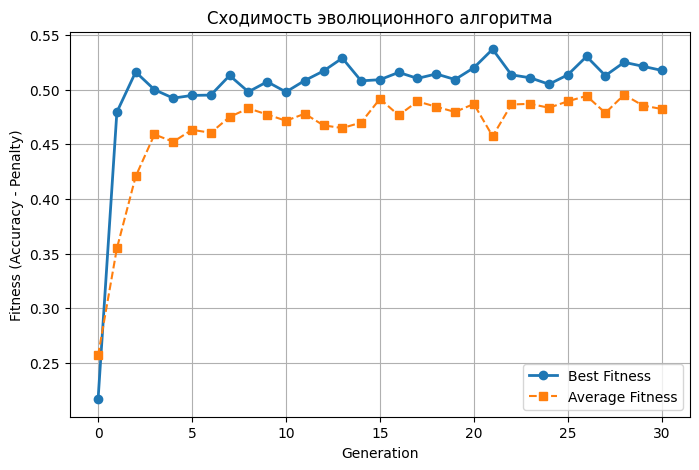

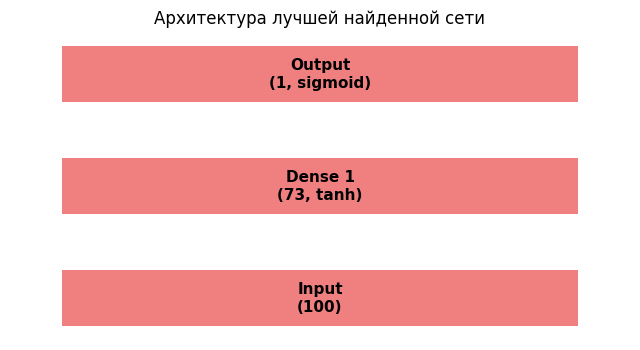

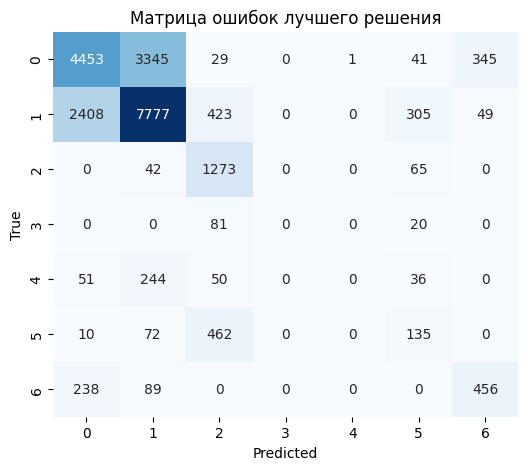

In [9]:
CONFIG = {
    "pop_size": 50,
    "generations": 30,
    "mutation_rate": 0.2,
    "elitism_count": 3,
    "max_epochs": 40,
    "early_stopping_patience": 5,
    "penalty_weight": 0.08,
    "val_size": 0.15,
    "test_size": 0.15,
    "batch_size": 4096,
    "num_classes": 7
}

runner = ExperimentRunner(CONFIG, device)
runner.run()